# Weakly supervised K0S momentum-scale DNN

This notebook learns momentum-scale maps directly from the \(K^0_S\to\pi^+\pi^-\) mass constraint.

The model does **not** use an event-by-event momentum-scale target. For each side, both daughter tracks enter the same corrected-mass loss:

\[
m_{\pi\pi}\left(s_1\mathbf p_1,\ s_2\mathbf p_2\right)
\longrightarrow m_{K^0_S}^{\mathrm{PDG}}.
\]

Side 0 and side 1 are trained independently. Within one side, positive and negative corrections are learned jointly through a charge-even and charge-odd decomposition:

\[
\log s_q(p_T,\phi,\eta)
=
A(p_T,\phi,\eta)
+
q\,B(p_T,\phi,\eta).
\]

Thus

\[
s_+=\exp(A+B),\qquad
s_-=\exp(A-B).
\]

The network output is explicitly bounded to a few percent, which prevents the unphysical 10% corrections seen in the unconstrained likelihood fit.


In [1]:
# ============================================================
# Imports and reproducibility
# ============================================================

from pathlib import Path
import copy
import math
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

try:
    import ROOT as root
except ImportError:
    root = None

seed = 12345

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch:", torch.__version__)
print("Device:", device)


Welcome to JupyROOT 6.30/06
PyTorch: 2.9.0+cu128
Device: cpu


In [ ]:
# ============================================================
# Configuration
# ============================================================

csv_file = Path(
    "/media/yoren/T7_Shield/sPHENIX/tracking/csvs/fit_k0s_pp_v1.csv"
)

map_root_file = Path(
    "output/k0s_momentum_scale_map_plots_cut03/k0s_dnn_momentum_scale_map.root"
)

map_csv_file = Path(
    "output/k0s_momentum_scale_map_plots_cut03/k0s_dnn_momentum_scale_grid.csv"
)

plot_dir = Path(
    "output/k0s_momentum_scale_map_plots_cut03"
)
plot_dir.mkdir(parents=True, exist_ok=True)

selection_name = "cut03"
training_parity = 0
validation_parity = 1 - training_parity

pdg_kshort_mass = 0.497611
pion_mass = 0.13957039

# Broad mass range used by the signal-plus-background loss.
fit_mass_minimum = 0.48
fit_mass_maximum = 0.52

# Fixed signal model. These can be scanned later using validation only.
signal_fraction = 0.77
signal_sigma = 0.004

# The true residual correction is expected to be a few percent.
maximum_even_log_scale = 0.025
maximum_odd_log_scale = 0.025
maximum_total_log_scale = 0.045

hidden_width = 54
hidden_layers = 3
dropout_probability = 0.05

batch_size = 1024
maximum_epochs = 1000
learning_rate = 2.0e-3
weight_decay = 2.0e-4
patience = 40

identity_penalty = 20.0
smoothness_penalty = 5.0
odd_component_penalty = 2.0

number_of_ensemble_models = 3

pt_edges = np.array([
    0.20, 0.30, 0.40, 0.55, 0.70,
    0.90, 1.20, 1.50, 2.00, 3.00, 5.00,
], dtype=np.float64)
pt_edges = np.array([
    0.20, 0.30, 0.40, 0.55, 0.70,
    0.90, 5.00,
], dtype=np.float64)

phi_edges = np.linspace(
    -math.pi,
    math.pi,
    25,
    dtype=np.float64,
)

eta_edges = np.linspace(
    -1.10,
    1.10,
    12,
    dtype=np.float64,
)


## Load and select candidates

The CSV contains one row per \(K^0_S\) pair and preserves both daughters in the same row.

For the first training pass:

- require both daughters to be on the same TPC side;
- train side 0 and side 1 independently;
- use one entry parity for training and the other for validation;
- use the stored established selection flags;
- keep a broad mass interval so the loss can model background.


In [3]:
# ============================================================
# Load CSV
# ============================================================

data = pd.read_csv(csv_file)

print("CSV rows:", len(data))
print(data.head())
print(data.dtypes)


CSV rows: 1372721
   entry  entry_parity  candidate_mask  has_kshort_details  same_side  side1  \
0      8             0               1                   1          0      0   
1     22             0               1                   1          0      0   
2     59             1               1                   1          1      1   
3     62             0               9                   1          1      1   
4     72             0               1                   1          0      0   

   charge1       px1       py1       pz1  ...   quality1  quality2  npoints1  \
0       -1  0.169507  0.183626 -0.409023  ...   3.711946  2.323870        38   
1       -1  0.584982  0.098902 -0.419766  ...   5.991875  2.187753        42   
2       -1 -0.140748 -0.180499  0.216816  ...   7.463751  1.364156        27   
3        1  0.176158  0.362576  0.769425  ...   2.649436  2.113664        28   
4       -1  0.132782 -0.175376 -0.206162  ...  12.265331  2.325334        37   

   npoints2  signed_

In [4]:
# ============================================================
# Selection
# ============================================================

if selection_name == "cut03":
    selection_flag = data["pass_cut03"].astype(bool)
elif selection_name == "cut07":
    selection_flag = data["pass_cut07"].astype(bool)
else:
    raise ValueError(
        "selection_name must be 'cut03' or 'cut07'"
    )

selected = data.loc[
    selection_flag
    & data["pass_pion_pid"].astype(bool)
    & data["pass_signed_delta_phi"].astype(bool)
    & data["same_side"].astype(bool)
    & (data["mass_before"] >= fit_mass_minimum)
    & (data["mass_before"] <= fit_mass_maximum)
].copy()

selected["side"] = selected["side1"].astype(int)

print("Selected rows:", len(selected))
print(selected.groupby(["side", "entry_parity"]).size())


Selected rows: 21263
side  entry_parity
0     0               5790
      1               5629
1     0               4944
      1               4900
dtype: int64


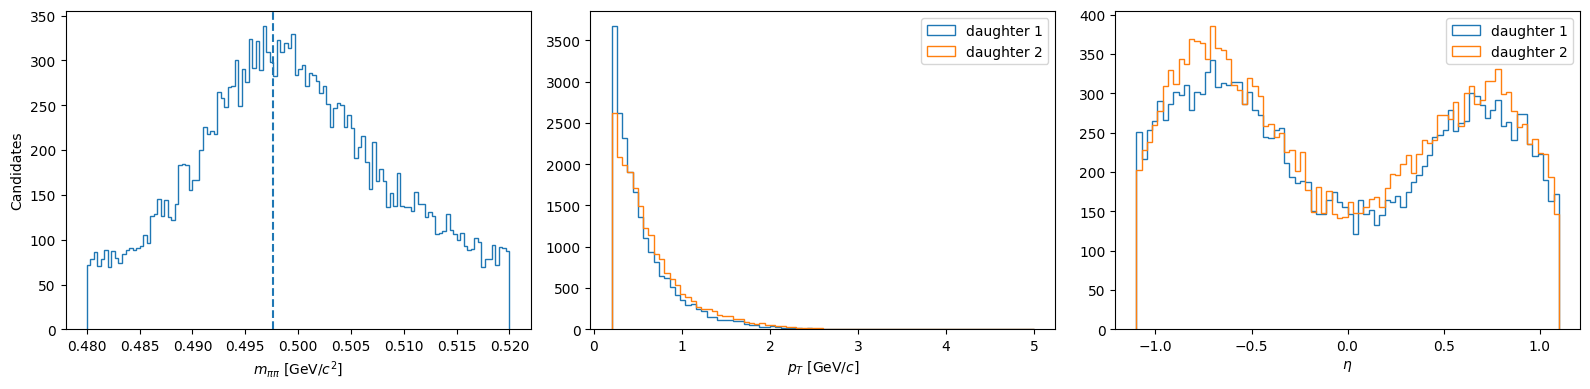

In [5]:
# ============================================================
# Quick input QA
# ============================================================

figure, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4),
)

axes[0].hist(
    selected["mass_before"],
    bins=120,
    range=(fit_mass_minimum, fit_mass_maximum),
    histtype="step",
)
axes[0].axvline(
    pdg_kshort_mass,
    linestyle="--",
)
axes[0].set_xlabel(r"$m_{\pi\pi}$ [GeV/$c^2$]")
axes[0].set_ylabel("Candidates")

axes[1].hist(
    selected["pt1"],
    bins=80,
    range=(0.2, 5.0),
    histtype="step",
    label="daughter 1",
)
axes[1].hist(
    selected["pt2"],
    bins=80,
    range=(0.2, 5.0),
    histtype="step",
    label="daughter 2",
)
axes[1].set_xlabel(r"$p_T$ [GeV/$c$]")
axes[1].legend()

axes[2].hist(
    selected["eta1"],
    bins=80,
    range=(-1.1, 1.1),
    histtype="step",
    label="daughter 1",
)
axes[2].hist(
    selected["eta2"],
    bins=80,
    range=(-1.1, 1.1),
    histtype="step",
    label="daughter 2",
)
axes[2].set_xlabel(r"$\eta$")
axes[2].legend()

figure.tight_layout()
plt.show()


## Dataset and model

The network sees only single-track phase-space information:

\[
\left[
\log p_T,\ \sin\phi,\ \cos\phi,\ \eta
\right].
\]

The charge is not an ordinary input. The network predicts two smooth functions:

- \(A\): charge-even correction;
- \(B\): charge-odd correction.

For a track with \(q=\pm1\),

\[
\log s_q=A+qB.
\]

Both tracks are evaluated by the same side-specific network and coupled through the corrected \(K^0_S\) mass.


In [6]:
# ============================================================
# Numerical helpers
# ============================================================

def invariant_mass_torch(
    momentum1,
    momentum2,
    mass1=pion_mass,
    mass2=pion_mass,
):
    energy1 = torch.sqrt(
        torch.sum(momentum1 * momentum1, dim=1)
        + mass1 * mass1
    )

    energy2 = torch.sqrt(
        torch.sum(momentum2 * momentum2, dim=1)
        + mass2 * mass2
    )

    total = momentum1 + momentum2

    mass_squared = (
        (energy1 + energy2) ** 2
        - torch.sum(total * total, dim=1)
    )

    return torch.sqrt(
        torch.clamp(mass_squared, min=0.0)
    )


def make_track_features(pt, phi, eta):
    return np.column_stack([
        np.log(np.clip(pt, 1.0e-4, None)),
        np.sin(phi),
        np.cos(phi),
        eta,
    ]).astype(np.float32)


In [7]:
# ============================================================
# Pair dataset
# ============================================================

class KshortPairDataset(Dataset):
    def __init__(self, frame):
        self.features1 = torch.from_numpy(
            make_track_features(
                frame["pt1"].to_numpy(),
                frame["phi1"].to_numpy(),
                frame["eta1"].to_numpy(),
            )
        )

        self.features2 = torch.from_numpy(
            make_track_features(
                frame["pt2"].to_numpy(),
                frame["phi2"].to_numpy(),
                frame["eta2"].to_numpy(),
            )
        )

        self.charge1 = torch.from_numpy(
            frame["charge1"].to_numpy(
                dtype=np.float32
            )
        )

        self.charge2 = torch.from_numpy(
            frame["charge2"].to_numpy(
                dtype=np.float32
            )
        )

        self.momentum1 = torch.from_numpy(
            frame[
                ["px1", "py1", "pz1"]
            ].to_numpy(dtype=np.float32)
        )

        self.momentum2 = torch.from_numpy(
            frame[
                ["px2", "py2", "pz2"]
            ].to_numpy(dtype=np.float32)
        )

        self.mass_before = torch.from_numpy(
            frame["mass_before"].to_numpy(
                dtype=np.float32
            )
        )

    def __len__(self):
        return len(self.mass_before)

    def __getitem__(self, index):
        return {
            "features1": self.features1[index],
            "features2": self.features2[index],
            "charge1": self.charge1[index],
            "charge2": self.charge2[index],
            "momentum1": self.momentum1[index],
            "momentum2": self.momentum2[index],
            "mass_before": self.mass_before[index],
        }


In [8]:
# ============================================================
# Charge-even / charge-odd DNN
# ============================================================

class MomentumScaleNetwork(nn.Module):
    def __init__(
        self,
        input_dimension=4,
        hidden_width=32,
        hidden_layers=2,
        dropout_probability=0.05,
    ):
        super().__init__()

        layers = []
        width = input_dimension

        for _ in range(hidden_layers):
            layers.extend([
                nn.Linear(width, hidden_width),
                nn.SiLU(),
                nn.Dropout(dropout_probability),
            ])
            width = hidden_width

        self.trunk = nn.Sequential(*layers)
        self.output = nn.Linear(width, 2)

        # Start exactly at no correction.
        nn.init.zeros_(self.output.weight)
        nn.init.zeros_(self.output.bias)

    def components(self, features):
        raw = self.output(self.trunk(features))

        even_component = (
            maximum_even_log_scale
            * torch.tanh(raw[:, 0])
        )

        odd_component = (
            maximum_odd_log_scale
            * torch.tanh(raw[:, 1])
        )

        return even_component, odd_component

    def log_scale(self, features, charge):
        even_component, odd_component = self.components(
            features
        )

        combined = (
            even_component
            + charge * odd_component
        )

        return torch.clamp(
            combined,
            min=-maximum_total_log_scale,
            max=maximum_total_log_scale,
        )

    def scale(self, features, charge):
        return torch.exp(
            self.log_scale(features, charge)
        )


## Weakly supervised loss

The main term is a signal-plus-background negative log likelihood of the corrected mass.

Additional regularization terms are essential:

- **identity penalty:** keeps the residual correction close to one;
- **odd-component penalty:** prevents an unnecessarily large positive/negative split;
- **smoothness penalty:** requires nearby phase-space points to have similar corrections.

The map strength is therefore learned only when it improves the mass likelihood enough to overcome these penalties.


In [9]:
# ============================================================
# Loss
# ============================================================

def mass_nll(corrected_mass):
    gaussian = (
        1.0
        / (
            math.sqrt(2.0 * math.pi)
            * signal_sigma
        )
        * torch.exp(
            -0.5
            * (
                (
                    corrected_mass
                    - pdg_kshort_mass
                )
                / signal_sigma
            ) ** 2
        )
    )

    uniform = (
        1.0
        / (
            fit_mass_maximum
            - fit_mass_minimum
        )
    )

    probability = (
        signal_fraction * gaussian
        + (1.0 - signal_fraction) * uniform
    )

    return -torch.log(
        torch.clamp(
            probability,
            min=1.0e-12,
        )
    ).mean()


def perturb_features(features):
    perturbed = features.clone()

    # Small local perturbations in log(pT), sin(phi), cos(phi), eta.
    noise = torch.randn_like(perturbed)

    perturbed[:, 0] += 0.025 * noise[:, 0]
    perturbed[:, 1] += 0.025 * noise[:, 1]
    perturbed[:, 2] += 0.025 * noise[:, 2]
    perturbed[:, 3] += 0.025 * noise[:, 3]

    return perturbed


def calculate_batch_loss(model, batch):
    features1 = batch["features1"].to(device)
    features2 = batch["features2"].to(device)

    charge1 = batch["charge1"].to(device)
    charge2 = batch["charge2"].to(device)

    momentum1 = batch["momentum1"].to(device)
    momentum2 = batch["momentum2"].to(device)

    log_scale1 = model.log_scale(
        features1,
        charge1,
    )

    log_scale2 = model.log_scale(
        features2,
        charge2,
    )

    scale1 = torch.exp(log_scale1)
    scale2 = torch.exp(log_scale2)

    corrected_momentum1 = (
        scale1[:, None] * momentum1
    )

    corrected_momentum2 = (
        scale2[:, None] * momentum2
    )

    corrected_mass = invariant_mass_torch(
        corrected_momentum1,
        corrected_momentum2,
    )

    likelihood_loss = mass_nll(corrected_mass)

    identity_loss = (
        torch.mean(log_scale1 ** 2)
        + torch.mean(log_scale2 ** 2)
    )

    even1, odd1 = model.components(features1)
    even2, odd2 = model.components(features2)

    odd_loss = (
        torch.mean(odd1 ** 2)
        + torch.mean(odd2 ** 2)
    )

    perturbed1 = perturb_features(features1)
    perturbed2 = perturb_features(features2)

    smoothness_loss = (
        torch.mean(
            (
                model.log_scale(
                    perturbed1,
                    charge1,
                )
                - log_scale1
            ) ** 2
        )
        + torch.mean(
            (
                model.log_scale(
                    perturbed2,
                    charge2,
                )
                - log_scale2
            ) ** 2
        )
    )

    total_loss = (
        likelihood_loss
        + identity_penalty * identity_loss
        + odd_component_penalty * odd_loss
        + smoothness_penalty * smoothness_loss
    )

    return {
        "total": total_loss,
        "nll": likelihood_loss,
        "identity": identity_loss,
        "odd": odd_loss,
        "smoothness": smoothness_loss,
        "corrected_mass": corrected_mass.detach(),
    }


In [10]:
# ============================================================
# Evaluation
# ============================================================

@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()

    losses = []
    corrected_masses = []
    original_masses = []

    for batch in loader:
        result = calculate_batch_loss(
            model,
            batch,
        )

        losses.append(
            result["total"].item()
        )

        corrected_masses.append(
            result["corrected_mass"]
            .cpu()
            .numpy()
        )

        original_masses.append(
            batch["mass_before"]
            .numpy()
        )

    return {
        "loss": float(np.mean(losses)),
        "mass_before": np.concatenate(
            original_masses
        ),
        "mass_after": np.concatenate(
            corrected_masses
        ),
    }


def peak_metrics(values):
    values = np.asarray(values)

    signal_window = values[
        (values >= 0.47)
        & (values <= 0.53)
    ]

    if len(signal_window) == 0:
        return {
            "mean": np.nan,
            "width": np.nan,
            "entries": 0,
        }

    return {
        "mean": float(
            np.mean(signal_window)
        ),
        "width": float(
            np.std(
                signal_window,
                ddof=1,
            )
        ),
        "entries": int(
            len(signal_window)
        ),
    }


In [11]:
# ============================================================
# Training one side and one random seed
# ============================================================

def train_one_model(
    side,
    model_seed,
):
    torch.manual_seed(model_seed)
    np.random.seed(model_seed)

    side_frame = selected.loc[
        selected["side"] == side
    ].copy()

    training_frame = side_frame.loc[
        side_frame["entry_parity"]
        == training_parity
    ]

    validation_frame = side_frame.loc[
        side_frame["entry_parity"]
        == validation_parity
    ]

    print(
        f"side {side}, seed {model_seed}: "
        f"training={len(training_frame)}, "
        f"validation={len(validation_frame)}"
    )

    training_dataset = KshortPairDataset(
        training_frame
    )

    validation_dataset = KshortPairDataset(
        validation_frame
    )

    training_loader = DataLoader(
        training_dataset,
        batch_size=min(
            batch_size,
            max(1, len(training_dataset)),
        ),
        shuffle=True,
        drop_last=False,
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=min(
            batch_size,
            max(1, len(validation_dataset)),
        ),
        shuffle=False,
        drop_last=False,
    )

    model = MomentumScaleNetwork(
        hidden_width=hidden_width,
        hidden_layers=hidden_layers,
        dropout_probability=dropout_probability,
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=12,
        min_lr=1.0e-5,
    )

    best_state = copy.deepcopy(
        model.state_dict()
    )

    best_validation_loss = np.inf
    epochs_without_improvement = 0

    history = {
        "training_loss": [],
        "validation_loss": [],
    }

    for epoch in range(maximum_epochs):
        model.train()

        batch_losses = []

        for batch in training_loader:
            optimizer.zero_grad()

            result = calculate_batch_loss(
                model,
                batch,
            )

            result["total"].backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0,
            )

            optimizer.step()

            batch_losses.append(
                result["total"].item()
            )

        training_loss = float(
            np.mean(batch_losses)
        )

        validation_result = evaluate_model(
            model,
            validation_loader,
        )

        validation_loss = validation_result[
            "loss"
        ]

        scheduler.step(validation_loss)

        history["training_loss"].append(
            training_loss
        )

        history["validation_loss"].append(
            validation_loss
        )

        if (
            validation_loss
            < best_validation_loss - 1.0e-5
        ):
            best_validation_loss = (
                validation_loss
            )

            best_state = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epoch % 25 == 0:
            print(
                f"  epoch={epoch:3d}, "
                f"train={training_loss:.6f}, "
                f"validation={validation_loss:.6f}"
            )

        if (
            epochs_without_improvement
            >= patience
        ):
            print(
                f"  early stopping at epoch "
                f"{epoch}"
            )
            break

    model.load_state_dict(best_state)

    training_result = evaluate_model(
        model,
        training_loader,
    )

    validation_result = evaluate_model(
        model,
        validation_loader,
    )

    return {
        "model": model,
        "history": history,
        "training": training_result,
        "validation": validation_result,
    }


## Train an ensemble

A small ensemble averages over random initialization and reduces statistical fluctuations in the final map. Each side is trained separately, but within each side the positive and negative scales are coupled through every \(K^0_S\) candidate.


In [ ]:
# ============================================================
# Train
# ============================================================

models = {
    0: [],
    1: [],
}

training_results = {
    0: [],
    1: [],
}

for side in [0, 1]:
    for ensemble_index in range(
        number_of_ensemble_models
    ):
        model_seed = (
            seed
            + 1000 * side
            + ensemble_index
        )

        result = train_one_model(
            side,
            model_seed,
        )

        models[side].append(
            result["model"]
        )

        training_results[side].append(
            result
        )


side 0, seed 12345: training=5790, validation=5629
  epoch=  0, train=-3.110331, validation=-3.153153


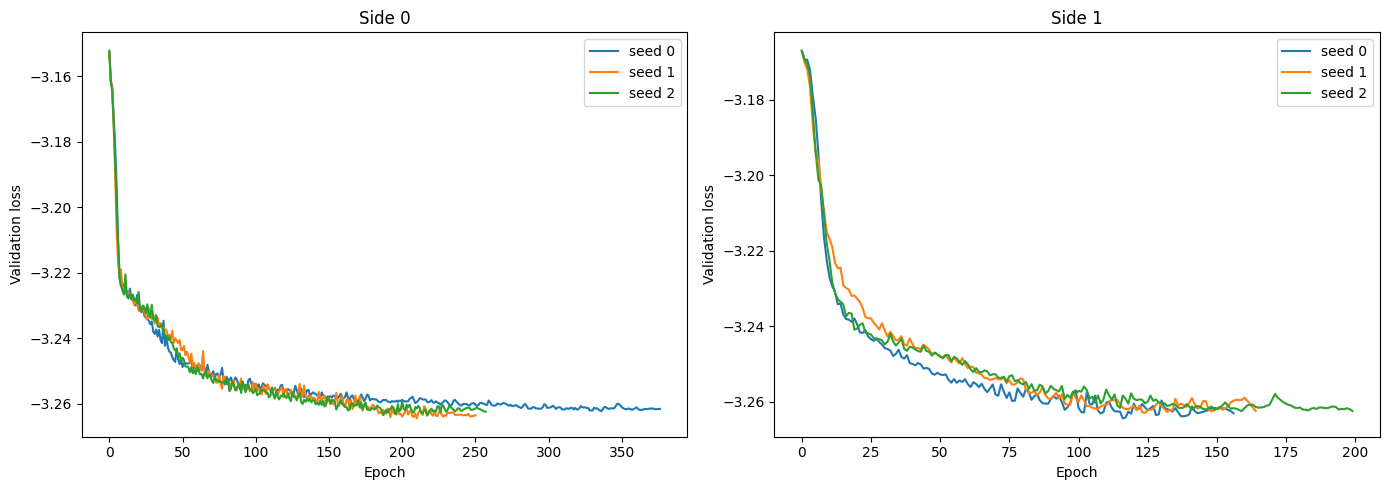

In [ ]:
# ============================================================
# Training curves
# ============================================================

figure, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

for side in [0, 1]:
    for index, result in enumerate(
        training_results[side]
    ):
        axes[side].plot(
            result["history"][
                "validation_loss"
            ],
            label=f"seed {index}",
        )

    axes[side].set_xlabel("Epoch")
    axes[side].set_ylabel("Validation loss")
    axes[side].set_title(f"Side {side}")
    axes[side].legend()

figure.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Ensemble prediction
# ============================================================

@torch.no_grad()
def ensemble_track_scale(
    side,
    charge,
    pt,
    phi,
    eta,
):
    pt = np.asarray(pt, dtype=np.float32)
    phi = np.asarray(phi, dtype=np.float32)
    eta = np.asarray(eta, dtype=np.float32)
    charge = np.asarray(
        charge,
        dtype=np.float32,
    )

    features = torch.from_numpy(
        make_track_features(
            pt,
            phi,
            eta,
        )
    ).to(device)

    charge_tensor = torch.from_numpy(
        charge
    ).to(device)

    predictions = []

    for model in models[side]:
        model.eval()

        prediction = model.scale(
            features,
            charge_tensor,
        )

        predictions.append(
            prediction.cpu().numpy()
        )

    return np.mean(
        predictions,
        axis=0,
    )


In [ ]:
# ============================================================
# Independent validation mass
# ============================================================

def corrected_mass_numpy(
    frame,
    side,
):
    scale1 = ensemble_track_scale(
        side=side,
        charge=frame["charge1"].to_numpy(),
        pt=frame["pt1"].to_numpy(),
        phi=frame["phi1"].to_numpy(),
        eta=frame["eta1"].to_numpy(),
    )

    scale2 = ensemble_track_scale(
        side=side,
        charge=frame["charge2"].to_numpy(),
        pt=frame["pt2"].to_numpy(),
        phi=frame["phi2"].to_numpy(),
        eta=frame["eta2"].to_numpy(),
    )

    momentum1 = frame[
        ["px1", "py1", "pz1"]
    ].to_numpy(dtype=np.float64)

    momentum2 = frame[
        ["px2", "py2", "pz2"]
    ].to_numpy(dtype=np.float64)

    momentum1 *= scale1[:, None]
    momentum2 *= scale2[:, None]

    energy1 = np.sqrt(
        np.sum(momentum1 ** 2, axis=1)
        + pion_mass ** 2
    )

    energy2 = np.sqrt(
        np.sum(momentum2 ** 2, axis=1)
        + pion_mass ** 2
    )

    total = momentum1 + momentum2

    mass_squared = (
        (energy1 + energy2) ** 2
        - np.sum(total ** 2, axis=1)
    )

    return np.sqrt(
        np.clip(
            mass_squared,
            0.0,
            None,
        )
    )


validation_outputs = {}

for side in [0, 1]:
    validation_frame = selected.loc[
        (selected["side"] == side)
        & (
            selected["entry_parity"]
            == validation_parity
        )
    ].copy()

    mass_before = validation_frame[
        "mass_before"
    ].to_numpy()

    mass_after = corrected_mass_numpy(
        validation_frame,
        side,
    )

    validation_outputs[side] = {
        "frame": validation_frame,
        "mass_before": mass_before,
        "mass_after": mass_after,
    }

    print(
        f"side {side} before:",
        peak_metrics(mass_before),
    )

    print(
        f"side {side} after:",
        peak_metrics(mass_after),
    )


side 0 before: {'mean': 0.49970934027089897, 'width': 0.009118980146983651, 'entries': 5629}
side 0 after: {'mean': 0.498008563259863, 'width': 0.00887619388548606, 'entries': 5627}
side 1 before: {'mean': 0.49931598702215707, 'width': 0.009116814817009036, 'entries': 4900}
side 1 after: {'mean': 0.4977001760545047, 'width': 0.008764807210471577, 'entries': 4900}


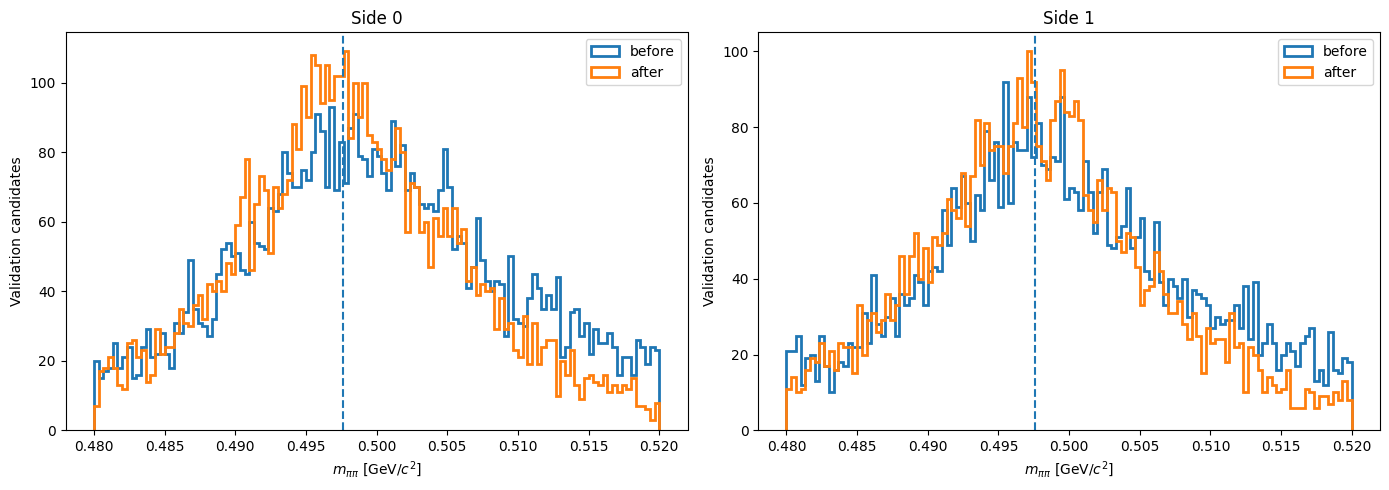

In [ ]:
# ============================================================
# Validation mass plots
# ============================================================

figure, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

for side in [0, 1]:
    output = validation_outputs[side]

    axes[side].hist(
        output["mass_before"],
        bins=120,
        range=(
            fit_mass_minimum,
            fit_mass_maximum,
        ),
        histtype="step",
        linewidth=2,
        label="before",
    )

    axes[side].hist(
        output["mass_after"],
        bins=120,
        range=(
            fit_mass_minimum,
            fit_mass_maximum,
        ),
        histtype="step",
        linewidth=2,
        label="after",
    )

    axes[side].axvline(
        pdg_kshort_mass,
        linestyle="--",
    )

    axes[side].set_xlabel(
        r"$m_{\pi\pi}$ [GeV/$c^2$]"
    )
    axes[side].set_ylabel("Validation candidates")
    axes[side].set_title(f"Side {side}")
    axes[side].legend()

figure.tight_layout()
plt.show()


## Inspect learned positive and negative maps

The plots below are direct network predictions, not candidate-by-candidate inferred targets. The correction must remain close to one and show stable, smooth opposite-charge structure when supported by the validation sample.


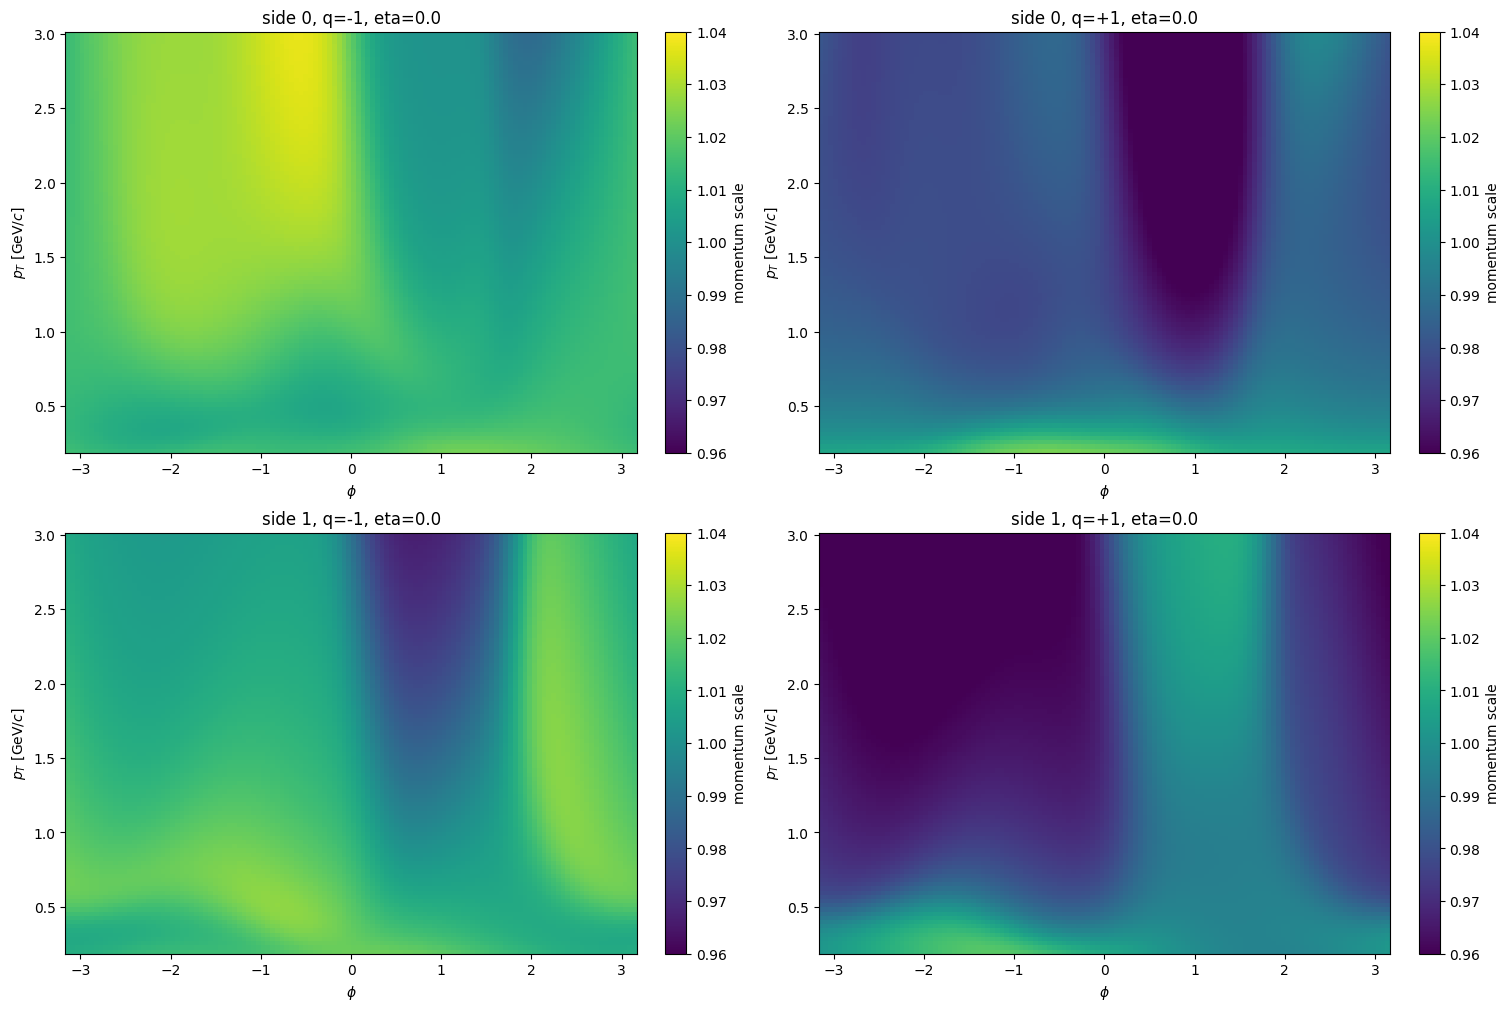

In [ ]:
# ============================================================
# Example pT-phi maps at fixed eta
# ============================================================

display_eta = 0.0

pt_display = np.linspace(
    0.20,
    3.00,
    100,
)

phi_display = np.linspace(
    -math.pi,
    math.pi,
    120,
)

pt_mesh, phi_mesh = np.meshgrid(
    pt_display,
    phi_display,
    indexing="ij",
)

figure, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10),
    constrained_layout=True,
)

for side in [0, 1]:
    for charge_index, charge in enumerate(
        [-1, 1]
    ):
        scale = ensemble_track_scale(
            side=side,
            charge=np.full(
                pt_mesh.size,
                charge,
                dtype=np.float32,
            ),
            pt=pt_mesh.ravel(),
            phi=phi_mesh.ravel(),
            eta=np.full(
                pt_mesh.size,
                display_eta,
                dtype=np.float32,
            ),
        ).reshape(pt_mesh.shape)

        axis = axes[side, charge_index]

        image = axis.pcolormesh(
            phi_display,
            pt_display,
            scale,
            shading="auto",
            vmin=0.96,
            vmax=1.04,
        )

        axis.set_xlabel(r"$\phi$")
        axis.set_ylabel(
            r"$p_T$ [GeV/$c$]"
        )
        axis.set_title(
            f"side {side}, q={charge:+d}, "
            f"eta={display_eta:.1f}"
        )

        figure.colorbar(
            image,
            ax=axis,
            label="momentum scale",
        )

plt.show()


## Export map

The final grid is written both as CSV and, when PyROOT is available, as a ROOT file compatible with the existing momentum-scale application code:

```text
side0/qminus/h3_momentum_scale
side0/qplus/h3_momentum_scale
side1/qminus/h3_momentum_scale
side1/qplus/h3_momentum_scale
```


In [ ]:
# ============================================================
# Evaluate map grid
# ============================================================

pt_centers = 0.5 * (
    pt_edges[:-1] + pt_edges[1:]
)

phi_centers = 0.5 * (
    phi_edges[:-1] + phi_edges[1:]
)

eta_centers = 0.5 * (
    eta_edges[:-1] + eta_edges[1:]
)

grid_rows = []

for side in [0, 1]:
    for charge in [-1, 1]:
        pt_grid, phi_grid, eta_grid = np.meshgrid(
            pt_centers,
            phi_centers,
            eta_centers,
            indexing="ij",
        )

        scale_grid = ensemble_track_scale(
            side=side,
            charge=np.full(
                pt_grid.size,
                charge,
                dtype=np.float32,
            ),
            pt=pt_grid.ravel(),
            phi=phi_grid.ravel(),
            eta=eta_grid.ravel(),
        )

        for pt, phi, eta, scale in zip(
            pt_grid.ravel(),
            phi_grid.ravel(),
            eta_grid.ravel(),
            scale_grid,
        ):
            grid_rows.append({
                "side": side,
                "charge": charge,
                "pt": pt,
                "phi": phi,
                "eta": eta,
                "momentum_scale": scale,
            })

map_grid = pd.DataFrame(grid_rows)
map_csv_file.parent.mkdir(
    parents=True,
    exist_ok=True,
)
map_grid.to_csv(
    map_csv_file,
    index=False,
)

print("Wrote:", map_csv_file)
print(
    map_grid.groupby(
        ["side", "charge"]
    )["momentum_scale"].agg(
        ["min", "max", "mean"]
    )
)


Wrote: output/k0s_momentum_scale_map_plots_cut03/k0s_dnn_momentum_scale_grid.csv
                  min       max      mean
side charge                              
0    -1      0.955997  1.040473  1.003832
      1      0.955997  1.038432  0.987038
1    -1      0.955997  1.029574  1.006209
      1      0.955997  1.018860  0.991897


In [ ]:
# ============================================================
# Write compatible ROOT TH3D maps
# ============================================================

if root is None:
    print(
        "PyROOT is unavailable. "
        "The CSV grid was written, but the ROOT map was not."
    )
else:
    from array import array

    map_root_file.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    output = root.TFile.Open(
        str(map_root_file),
        "RECREATE",
    )

    if not output or output.IsZombie():
        raise OSError(
            f"Could not create {map_root_file}"
        )

    root.TNamed(
        "method",
        (
            "weakly supervised charge-even/charge-odd DNN; "
            f"training parity={training_parity}; "
            f"validation parity={validation_parity}; "
            f"ensemble models={number_of_ensemble_models}"
        ),
    ).Write()

    for side in [0, 1]:
        side_directory = output.mkdir(
            f"side{side}"
        )

        for charge in [-1, 1]:
            charge_directory = (
                side_directory.mkdir(
                    "qplus"
                    if charge > 0
                    else "qminus"
                )
            )

            charge_directory.cd()

            histogram = root.TH3D(
                "h3_momentum_scale",
                (
                    "DNN momentum scale;"
                    "p_{T} [GeV/c];#phi;#eta"
                ),
                len(pt_edges) - 1,
                array("d", pt_edges),
                len(phi_edges) - 1,
                array("d", phi_edges),
                len(eta_edges) - 1,
                array("d", eta_edges),
            )

            subset = map_grid.loc[
                (map_grid["side"] == side)
                & (
                    map_grid["charge"]
                    == charge
                )
            ]

            for row in subset.itertuples(
                index=False
            ):
                pt_bin = (
                    histogram.GetXaxis()
                    .FindBin(row.pt)
                )

                phi_bin = (
                    histogram.GetYaxis()
                    .FindBin(row.phi)
                )

                eta_bin = (
                    histogram.GetZaxis()
                    .FindBin(row.eta)
                )

                histogram.SetBinContent(
                    pt_bin,
                    phi_bin,
                    eta_bin,
                    float(row.momentum_scale),
                )

            histogram.Write()

    output.Close()

    print("Wrote:", map_root_file)


Wrote: output/k0s_momentum_scale_map_plots_cut03/k0s_dnn_momentum_scale_map.root


## Validation rules

Accept a map only when all of the following hold on the untouched validation half:

1. the \(K^0_S\) peak moves closer to the PDG mass;
2. the width does not become worse;
3. the map remains within the expected few-percent range;
4. independent random seeds give similar maps;
5. retraining with odd entries and validating on even entries gives compatible results;
6. applying the map to \(\Lambda\), \(\bar\Lambda\), \(\phi\), and \(D^0\) does not systematically worsen their masses.

The regularization strengths and maximum scale range must be chosen using validation only.
